# American Sign Language (ASL) Classification

### 1. Setup

In [ ]:
import os, random, json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras.applications.efficientnet import EfficientNetB0, preprocess_input
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dropout, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

### 2. Mounting Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

base_dir = "/content/drive/MyDrive/PBL/ASL_CNN/ASL_Gestures_36_Classes"
train_dir = os.path.join(base_dir, "train")
test_dir  = os.path.join(base_dir, "test")
os.makedirs("/content/asl_results", exist_ok=True)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### 3. Verifying Dataset

In [ ]:
def count_images(path):
    total = 0
    cls_counts = {}
    for cls in sorted(os.listdir(path)):
        p = os.path.join(path, cls)
        if os.path.isdir(p):
            count = len([f for f in os.listdir(p) if not f.startswith('.')])
            cls_counts[cls] = count
            total += count
    return cls_counts, total

train_counts, train_total = count_images(train_dir)
test_counts, test_total = count_images(test_dir)

print(f"\n Train images: {train_total}")
print(f" Test images : {test_total}")


 Train images: 2011
 Test images : 504


### 4. Visualizing Few Samples


Showing random samples from train folder...


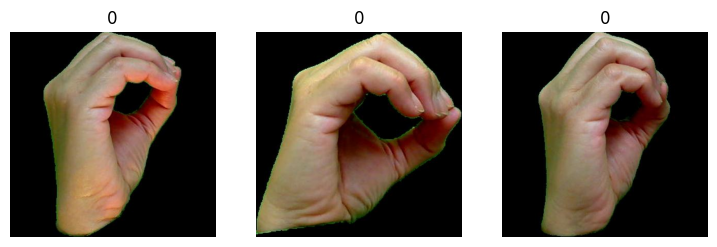

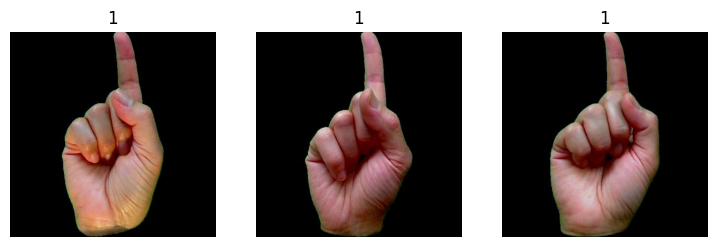

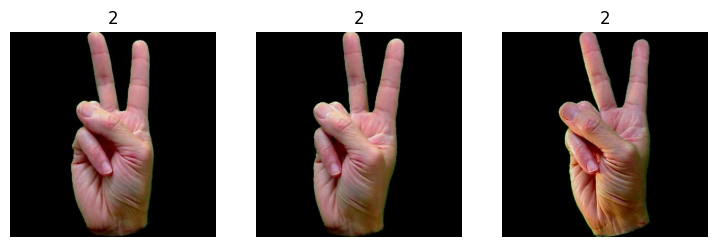

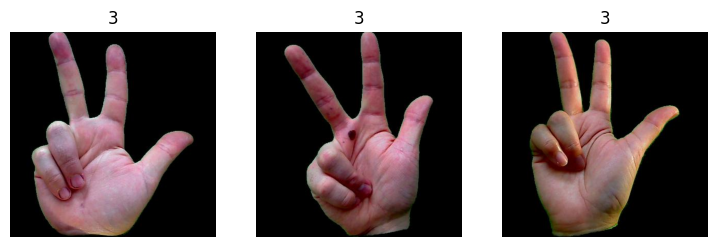

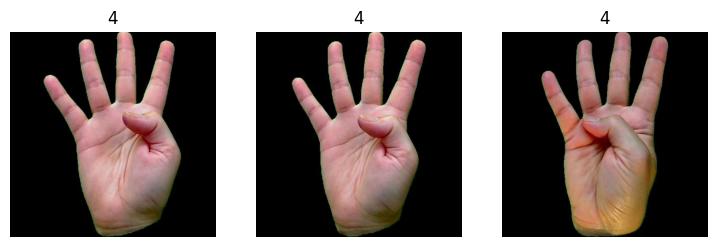

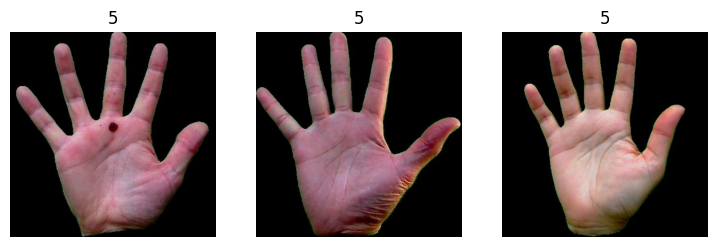


Showing random samples from test folder...


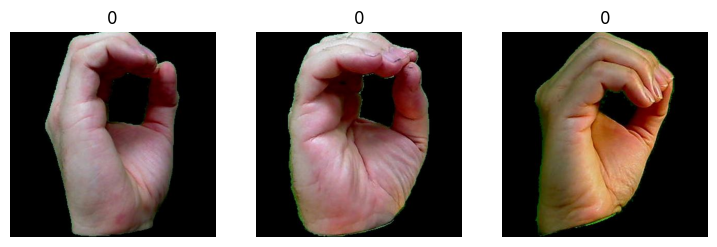

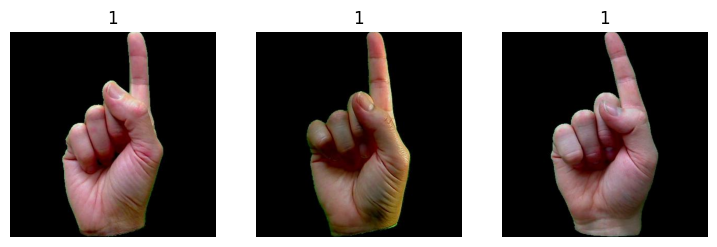

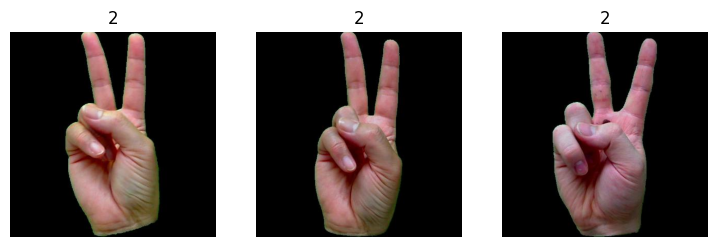

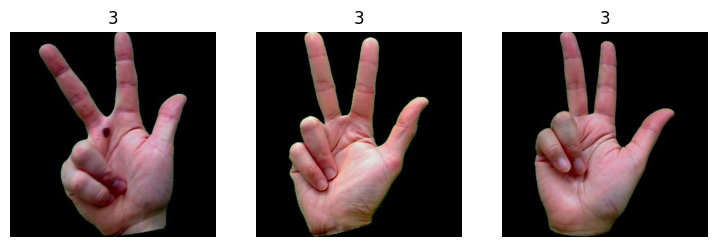

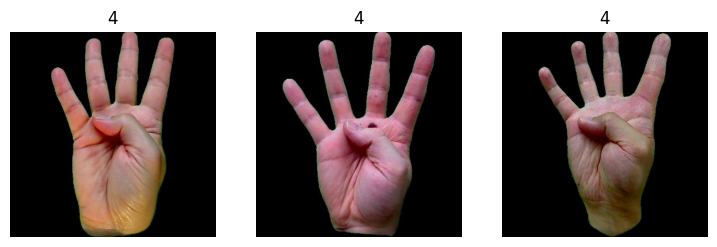

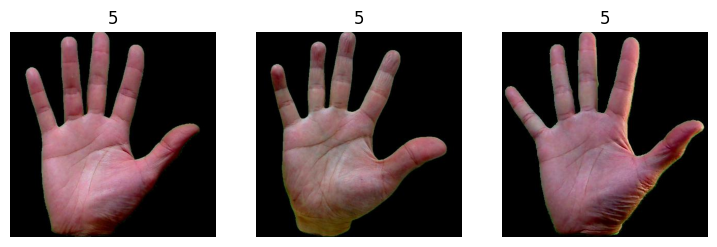

In [ ]:
def show_samples(folder, n_classes=6, n_images=3):
    print(f"\nShowing random samples from {os.path.basename(folder)} folder...")
    classes = sorted(os.listdir(folder))[:n_classes]
    for cls in classes:
        cls_path = os.path.join(folder, cls)
        imgs = [f for f in os.listdir(cls_path) if not f.startswith('.')]
        random.shuffle(imgs)
        selected = imgs[:n_images]
        plt.figure(figsize=(9,3))
        for i, img_file in enumerate(selected):
            path = os.path.join(cls_path, img_file)
            try:
                img = Image.open(path).convert("RGB")
                plt.subplot(1, n_images, i+1)
                plt.imshow(img)
                plt.axis('off')
                plt.title(cls)
            except:
                continue
        plt.show()

show_samples(train_dir)
show_samples(test_dir)

### 5. Modern Dataset Loading

In [ ]:
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 16
VAL_SPLIT = 0.2
SEED = 42

# Loading datasets with correct normalization
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=VAL_SPLIT,
    subset="training",
    seed=SEED,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE
)
val_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=VAL_SPLIT,
    subset="validation",
    seed=SEED,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE
)
test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

# Getting class names before applying map and prefetch
class_names = train_ds.class_names
num_classes = len(class_names)
print(f"\nDetected {num_classes} classes")
print("Class names:", class_names)

# Apply EfficientNet preprocessing ([-1, 1] range)
def prep(img, label):
    return preprocess_input(img), label

train_ds = train_ds.map(prep, num_parallel_calls=tf.data.AUTOTUNE)
val_ds   = val_ds.map(prep, num_parallel_calls=tf.data.AUTOTUNE)
test_ds  = test_ds.map(prep, num_parallel_calls=tf.data.AUTOTUNE)

# Prefetch for performance
train_ds = train_ds.shuffle(1000).prefetch(tf.data.AUTOTUNE)
val_ds   = val_ds.prefetch(tf.data.AUTOTUNE)
test_ds  = test_ds.prefetch(tf.data.AUTOTUNE)

# Sanity checking
for imgs, lbls in train_ds.take(1):
    print("Batch shape:", imgs.shape, lbls.shape)
    print("Pixel range:", tf.reduce_min(imgs).numpy(), "to", tf.reduce_max(imgs).numpy())


Found 2011 files belonging to 36 classes.
Using 1609 files for training.
Found 2011 files belonging to 36 classes.
Using 402 files for validation.
Found 504 files belonging to 36 classes.

Detected 36 classes
Class names: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z']
Batch shape: (16, 224, 224, 3) (16,)
Pixel range: 0.0 to 254.91965


###  6. Model Building

In [ ]:
base_model = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(224,224,3))

# Unfreeze top 30 layers initially
for layer in base_model.layers[:-30]:
    layer.trainable = False
for layer in base_model.layers[-30:]:
    layer.trainable = True

x = GlobalAveragePooling2D()(base_model.output)
x = Dropout(0.4)(x)
output = Dense(num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

model.compile(optimizer=Adam(learning_rate=1e-4),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 4,095,687 (15.62 MB)

 Trainable params: 1,542,276 (5.88 MB)

 Non-trainable params: 2,553,411 (9.74 MB)

### 7. Callbacks

In [ ]:
callbacks = [
    EarlyStopping(monitor='val_accuracy', patience=4, restore_best_weights=True),
    ModelCheckpoint("/content/asl_results/best_model.keras", save_best_only=True, monitor='val_accuracy'),
    ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=2, min_lr=1e-6)
]

### 8. Phase 1: Training

In [ ]:
EPOCHS_PHASE1 = 6
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_PHASE1,
    verbose=1,
    callbacks=callbacks
)

Epoch 1/6
101/101 ━━━━━━━━━━━━━━━━━━━━ 227s 2s/step - accuracy: 0.1443 - loss: 3.3933 - val_accuracy: 0.5796 - val_loss: 2.3699 - learning_rate: 1.0000e-04
Epoch 2/6
101/101 ━━━━━━━━━━━━━━━━━━━━ 11s 56ms/step - accuracy: 0.6259 - loss: 2.1081 - val_accuracy: 0.8582 - val_loss: 1.1192 - learning_rate: 1.0000e-04
Epoch 3/6
101/101 ━━━━━━━━━━━━━━━━━━━━ 9s 45ms/step - accuracy: 0.8041 - loss: 1.2602 - val_accuracy: 0.8806 - val_loss: 0.6032 - learning_rate: 1.0000e-04
Epoch 4/6
101/101 ━━━━━━━━━━━━━━━━━━━━ 10s 43ms/step - accuracy: 0.8614 - loss: 0.8056 - val_accuracy: 0.9204 - val_loss: 0.4057 - learning_rate: 1.0000e-04
Epoch 5/6
101/101 ━━━━━━━━━━━━━━━━━━━━ 11s 55ms/step - accuracy: 0.9055 - loss: 0.5765 - val_accuracy: 0.9527 - val_loss: 0.3028 - learning_rate: 1.0000e-04
Epoch 6/6
101/101 ━━━━━━━━━━━━━━━━━━━━ 10s 50ms/step - accuracy: 0.9148 - loss: 0.4338 - val_accuracy: 0.9453 - val_loss: 0.2390 - learning_rate: 1.0000e-04


### 9. Phase 2: Fine-tuning (Unfreeze deeper layers)

In [ ]:
print("\nPhase 2: Unfreezing top 100 layers for fine-tuning...")

for layer in base_model.layers:
    layer.trainable = False
for layer in base_model.layers[-100:]:
    layer.trainable = True

model.compile(optimizer=Adam(learning_rate=1e-5),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

EPOCHS_PHASE2 = 10
history_fine = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_PHASE2,
    verbose=1,
    callbacks=callbacks
)


Phase 2: Unfreezing top 100 layers for fine-tuning...
Epoch 1/10
101/101 ━━━━━━━━━━━━━━━━━━━━ 80s 356ms/step - accuracy: 0.8244 - loss: 1.0967 - val_accuracy: 0.9104 - val_loss: 0.4771 - learning_rate: 1.0000e-05
Epoch 2/10
101/101 ━━━━━━━━━━━━━━━━━━━━ 10s 51ms/step - accuracy: 0.8778 - loss: 0.8580 - val_accuracy: 0.9179 - val_loss: 0.4421 - learning_rate: 1.0000e-05
Epoch 3/10
101/101 ━━━━━━━━━━━━━━━━━━━━ 9s 45ms/step - accuracy: 0.8813 - loss: 0.7329 - val_accuracy: 0.9254 - val_loss: 0.3848 - learning_rate: 1.0000e-05
Epoch 4/10
101/101 ━━━━━━━━━━━━━━━━━━━━ 10s 46ms/step - accuracy: 0.9016 - loss: 0.6245 - val_accuracy: 0.9279 - val_loss: 0.3387 - learning_rate: 1.0000e-05
Epoch 5/10
101/101 ━━━━━━━━━━━━━━━━━━━━ 10s 47ms/step - accuracy: 0.9150 - loss: 0.5202 - val_accuracy: 0.9353 - val_loss: 0.3054 - learning_rate: 1.0000e-05
Epoch 6/10
101/101 ━━━━━━━━━━━━━━━━━━━━ 10s 50ms/step - accuracy: 0.9159 - loss: 0.4780 - val_accuracy: 0.9428 - val_loss: 0.2790 - learning_rate: 1.0000e-

### 10. Evaluation

In [ ]:
model.load_weights("/content/asl_results/best_model.keras")
test_loss, test_acc = model.evaluate(test_ds, verbose=1)
print(f"\nFinal Test Accuracy: {test_acc*100:.2f}%")

32/32 ━━━━━━━━━━━━━━━━━━━━ 200s 6s/step - accuracy: 0.9489 - loss: 0.2315

Final Test Accuracy: 95.24%


### 11. Summary of All Accuracies

In [ ]:
train_acc = history_fine.history['accuracy'][-1]
val_acc = history_fine.history['val_accuracy'][-1]
test_loss, test_acc = model.evaluate(test_ds, verbose=0)

print("\nFinal Model Performance Summary")
print(f"Training Accuracy   : {train_acc*100:.2f}%")
print(f"Validation Accuracy : {val_acc*100:.2f}%")
print(f"Testing Accuracy    : {test_acc*100:.2f}%")


Final Model Performance Summary
Training Accuracy   : 94.03%
Validation Accuracy : 95.52%
Testing Accuracy    : 95.24%


### 12. Plot Metrics

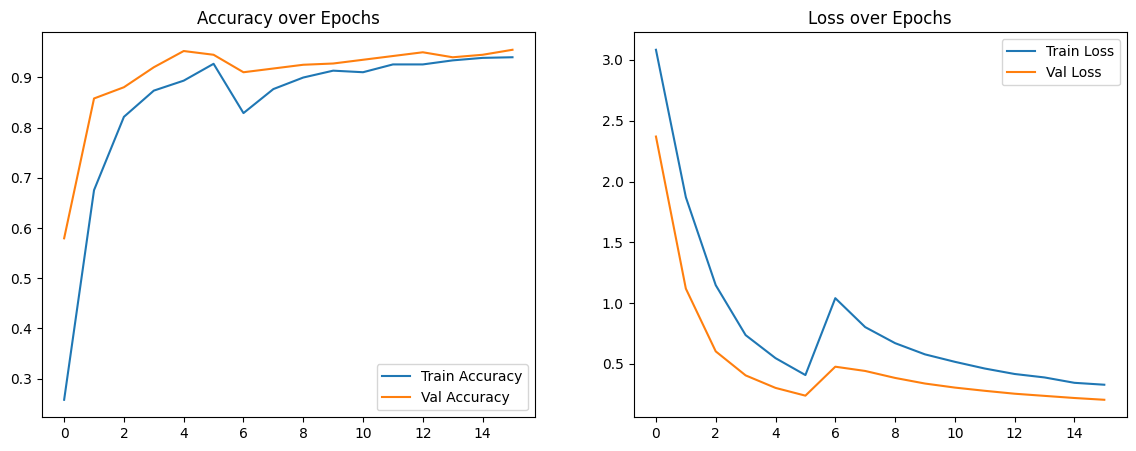

In [ ]:
def plot_history(h1, h2=None):
    acc = h1.history['accuracy'] + (h2.history['accuracy'] if h2 else [])
    val_acc = h1.history['val_accuracy'] + (h2.history['val_accuracy'] if h2 else [])
    loss = h1.history['loss'] + (h2.history['loss'] if h2 else [])
    val_loss = h1.history['val_loss'] + (h2.history['val_loss'] if h2 else [])

    plt.figure(figsize=(14,5))
    plt.subplot(1,2,1)
    plt.plot(acc, label="Train Accuracy")
    plt.plot(val_acc, label="Val Accuracy")
    plt.legend(); plt.title("Accuracy over Epochs")

    plt.subplot(1,2,2)
    plt.plot(loss, label="Train Loss")
    plt.plot(val_loss, label="Val Loss")
    plt.legend(); plt.title("Loss over Epochs")
    plt.show()

plot_history(history, history_fine)

### 13. Classification Report


In [ ]:
Y_pred = model.predict(test_ds, verbose=1)
y_pred = np.argmax(Y_pred, axis=1)

y_true = np.concatenate([y for x, y in test_ds], axis=0)

print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))

32/32 ━━━━━━━━━━━━━━━━━━━━ 14s 265ms/step

Classification Report:

              precision    recall  f1-score   support

           0       0.92      0.79      0.85        14
           1       0.93      1.00      0.97        14
           2       0.93      1.00      0.97        14
           3       1.00      1.00      1.00        14
           4       0.93      0.93      0.93        14
           5       0.93      0.93      0.93        14
           6       0.61      0.79      0.69        14
           7       1.00      1.00      1.00        14
           8       1.00      1.00      1.00        14
           9       1.00      1.00      1.00        14
           a       1.00      1.00      1.00        14
           b       1.00      1.00      1.00        14
           c       1.00      1.00      1.00        14
           d       1.00      0.93      0.96        14
           e       0.93      1.00      0.97        14
           f       1.00      1.00      1.00        14
           g  

### 14. Confusion Matrix

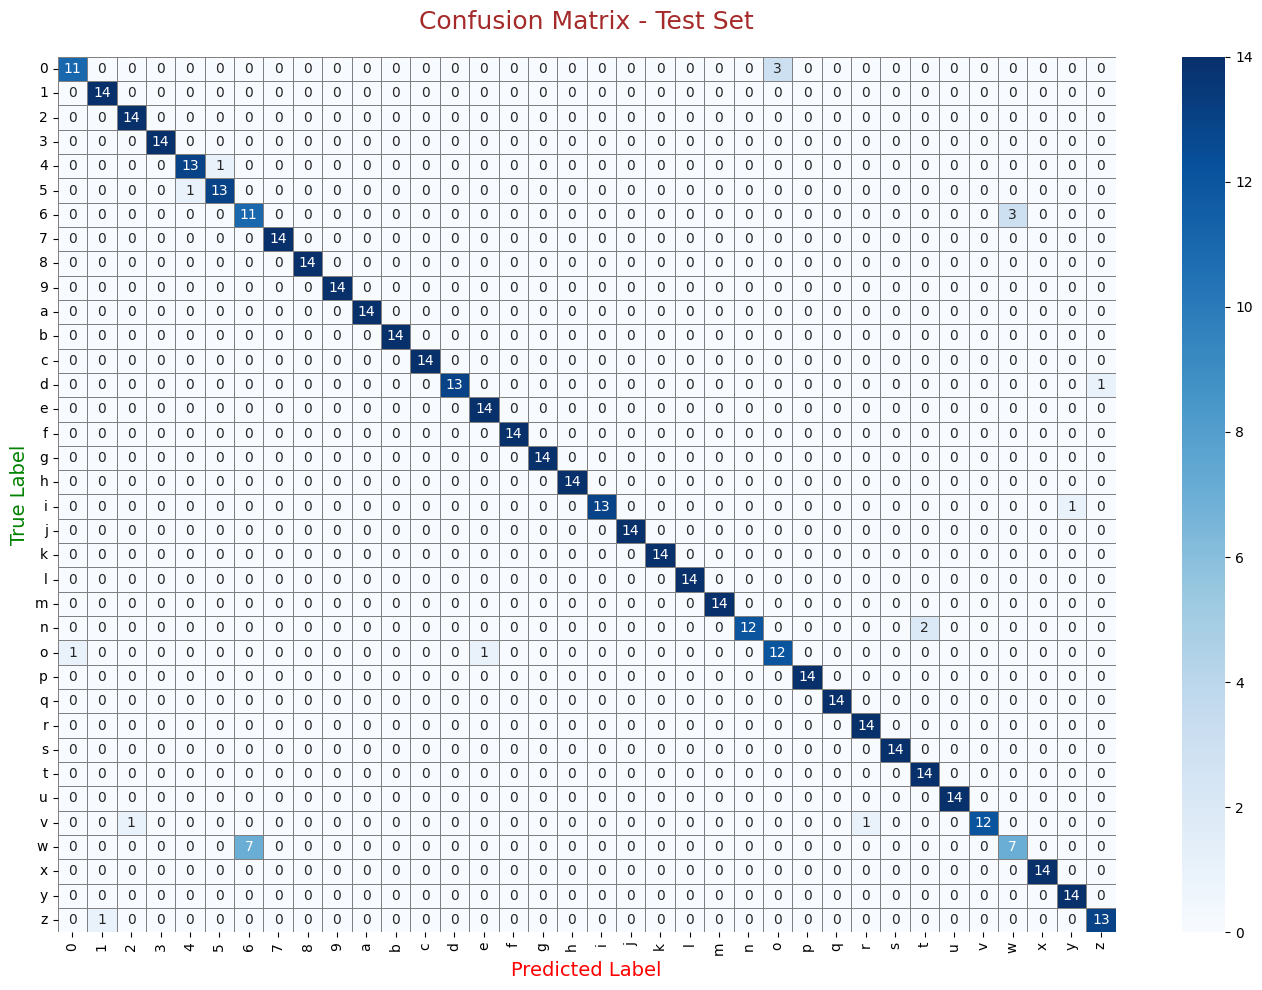

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Computing confusion matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(14, 10))
sns.heatmap(
    cm,
    annot=True,
    fmt='g',
    cmap='Blues',
    cbar=True,
    linewidths=0.5,
    linecolor='gray'
)

plt.title("Confusion Matrix - Test Set", fontsize=18, color='brown', pad=20)
plt.xlabel("Predicted Label", fontsize=14, color='red')
plt.ylabel("True Label", fontsize=14, color='green')

plt.xticks(np.arange(len(class_names)) + 0.5, class_names, rotation=90)
plt.yticks(np.arange(len(class_names)) + 0.5, class_names, rotation=0)

plt.tight_layout()
plt.show()


### 15. Saving the Model and Class Mapping

In [ ]:
model.save("/content/asl_results/final_asl_model.keras")
with open("/content/asl_results/class_indices.json", "w") as f:
    json.dump({i: name for i, name in enumerate(class_names)}, f)
print("\nModel and class mapping saved successfully!")


Model and class mapping saved successfully!


### 16. Inference Demo

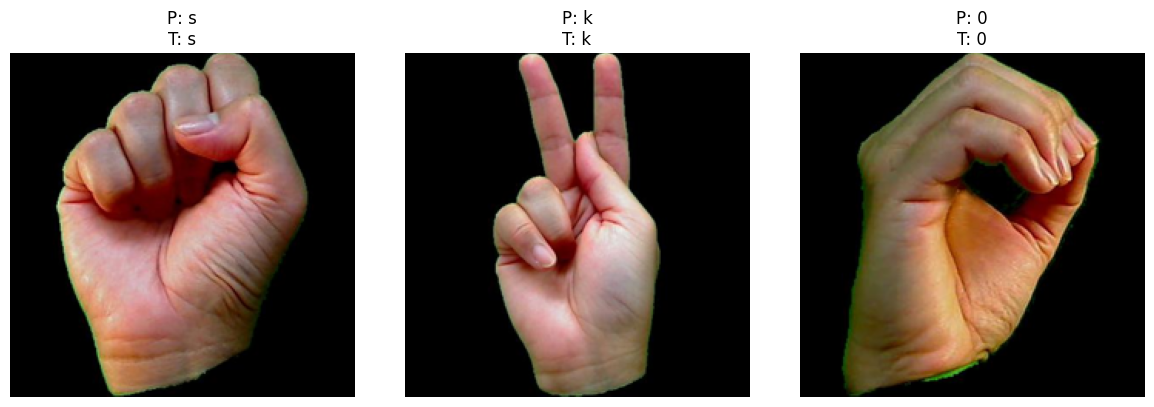

In [ ]:
import os, random
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import load_model
from tensorflow.keras.applications.efficientnet import preprocess_input
import json
from PIL import Image

# Loading model
model_path = "/content/asl_results/final_asl_model.keras"
model = load_model(model_path)

# Loading class names
with open("/content/asl_results/class_indices.json", "r") as f:
    class_dict = json.load(f)
class_names = list(class_dict.values())

# Test dataset path
test_dir = "/content/drive/MyDrive/PBL/ASL_CNN/ASL_Gestures_36_Classes/test"

# Picking 3 random test images
samples = []
for _ in range(3):
    test_class = random.choice(os.listdir(test_dir))
    test_class_path = os.path.join(test_dir, test_class)
    sample_file = random.choice(os.listdir(test_class_path))
    img_path = os.path.join(test_class_path, sample_file)
    samples.append((img_path, test_class))

# Creating a plot
plt.figure(figsize=(12, 4))

for i, (img_path, true_class) in enumerate(samples):
    # Load and preprocess each image
    img = Image.open(img_path).convert("RGB").resize((224, 224))
    img_array = np.expand_dims(np.array(img), axis=0)
    img_array = preprocess_input(img_array)

    # Prediction
    pred = model.predict(img_array, verbose=0)
    predicted_class_index = np.argmax(pred, axis=1)[0]
    predicted_class = class_names[predicted_class_index]

    # Display
    plt.subplot(1, 3, i + 1)
    plt.imshow(np.array(img))
    plt.title(f"P: {predicted_class}\nT: {true_class}")
    plt.axis("off")

plt.tight_layout()
plt.show()

###